In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning_utils import clean_dataset

In [2]:
raw_df = pd.read_csv('Huawei_BH_4G.csv')
df = clean_dataset(raw_df)

df = df.drop(['Avg_DL_Traffic_Active_User_missing','Avg_UL_Traffic_Active_User_missing'], axis=1)

### General Dataset Overview

In [3]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nDetailed info:")
df.info()

Shape: (404864, 24)

Data Types:
float64           11
bool               5
string[python]     3
datetime64[ns]     1
category           1
category           1
category           1
category           1
Name: count, dtype: int64

Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404864 entries, 0 to 404863
Data columns (total 24 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Date                             404864 non-null  datetime64[ns]
 1   eNodeB_Name                      404864 non-null  string        
 2   Frequency_band                   404864 non-null  category      
 3   Cell_FDD_TDD_Indication          404864 non-null  category      
 4   Cell_Name                        404864 non-null  string        
 5   LocalCell_Id                     404864 non-null  category      
 6   eNodeB_Function_Name             404864 non-null  string        
 7   Integrity  

In [4]:
# Missing flags summary
missing_flag_cols = ['DRC_wo_VoLTE_missing', 'Avg_DL_User_Thrput_kbps_missing', 'Avg_UL_User_Thrput_kbps_missing',
                    'Avg_DL_PRB_Usage_missing',
                    'Avg_UL_PRB_Usage_missing']

# Count of True/False per flag
for col in missing_flag_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))

# Count rows with any missing flag True
df['any_missing'] = df[missing_flag_cols].any(axis=1)
print("\nRows with any missing flag True:", df['any_missing'].sum())


DRC_wo_VoLTE_missing value counts:
DRC_wo_VoLTE_missing
False    401770
True       3094
Name: count, dtype: int64

Avg_DL_User_Thrput_kbps_missing value counts:
Avg_DL_User_Thrput_kbps_missing
False    402813
True       2051
Name: count, dtype: int64

Avg_UL_User_Thrput_kbps_missing value counts:
Avg_UL_User_Thrput_kbps_missing
False    402868
True       1996
Name: count, dtype: int64

Avg_DL_PRB_Usage_missing value counts:
Avg_DL_PRB_Usage_missing
False    403057
True       1807
Name: count, dtype: int64

Avg_UL_PRB_Usage_missing value counts:
Avg_UL_PRB_Usage_missing
False    403057
True       1807
Name: count, dtype: int64

Rows with any missing flag True: 3145


In [5]:
# Categorical summary
cat_cols = df.select_dtypes(include=['category']).columns
for col in cat_cols:
    print(f"\nColumns: {col}")
    print(df[col].value_counts(dropna=False))


Columns: Frequency_band
Frequency_band
20    155218
3     121383
28     77069
7      50636
40       558
Name: count, dtype: int64

Columns: Cell_FDD_TDD_Indication
Cell_FDD_TDD_Indication
CELL_FDD    404306
CELL_TDD       558
Name: count, dtype: int64

Columns: LocalCell_Id
LocalCell_Id
4      34921
6      34920
5      34766
1      31389
2      31389
3      31389
71     25391
73     25391
72     25391
11     21581
12     19952
13     19797
82     14701
83     14670
81     14577
14      5296
15      4628
16      4431
84      1112
85       992
86       864
110      403
112      403
113      403
111      403
201      279
202      279
200      279
132      279
131      279
130      279
133      279
120      248
122      248
123      248
121      248
203      248
100      217
101      217
102      217
103      217
252      217
251      217
250      217
253      217
61       186
62       186
63       186
18       124
7         31
8         31
9         31
Name: count, dtype: int64

Columns:

In [6]:
# Date summary
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print("Date Frequency Breakdown:")
print(df['Date'].dt.to_period('D').value_counts().sort_index())


Date Range: 2025-06-20 00:00:00 to 2025-07-20 23:00:00
Date Frequency Breakdown:
Date
2025-06-20    13035
2025-06-21    13032
2025-06-22    13047
2025-06-23    13056
2025-06-24    13048
2025-06-25    13061
2025-06-26    13068
2025-06-27    13043
2025-06-28    13037
2025-06-29    13038
2025-06-30    13054
2025-07-01    13063
2025-07-02    13063
2025-07-03    13079
2025-07-04    13070
2025-07-05    13061
2025-07-06    13060
2025-07-07    13052
2025-07-08    13063
2025-07-09    13045
2025-07-10    13060
2025-07-11    13072
2025-07-12    13069
2025-07-13    13078
2025-07-14    13075
2025-07-15    13074
2025-07-16    13085
2025-07-17    13069
2025-07-18    13075
2025-07-19    13069
2025-07-20    13063
Freq: D, Name: count, dtype: int64


In [7]:
# Descriptive stats for numeric columns
numeric_cols = df.select_dtypes(include=['float', 'int']).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CSSR_wo_VoLTE,404864.0,98.788193,8.815930,0.0,99.527900,99.81790,99.943800,100.0000
DRC_wo_VoLTE,404864.0,0.356545,1.011003,0.0,0.012375,0.13480,0.379300,100.0000
Avg_DL_User_Thrput_kbps,404864.0,16565.048602,12257.239451,0.0,7453.661000,14035.29780,22733.729525,177852.9880
UL_Traffic_Volume_GBytes,404864.0,0.662116,0.676938,0.0,0.195100,0.47220,0.913100,14.4677
Avg_UL_User_Thrput_kbps,404864.0,3913.133887,2545.521742,0.0,2361.806925,3409.27100,4788.082075,55755.4628
DL_Traffic_Volume_GBytes,404864.0,5.769072,4.626958,0.0,2.116600,4.72545,8.291250,44.1531
Avg_DL_Traffic_Active_User,404864.0,3.895844,11.135490,0.0,0.498000,1.15620,2.682600,363.6674
Avg_UL_Traffic_Active_User,404864.0,2.169364,6.219481,0.0,0.590500,1.27470,2.308300,412.8200
Avg_DL_PRB_Usage,404864.0,49.340940,28.576194,0.0,24.586650,46.52800,73.516550,99.9870
Avg_UL_PRB_Usage,404864.0,20.645587,13.219753,0.0,10.861075,17.43550,26.670800,99.6385


### Univariate Analysis

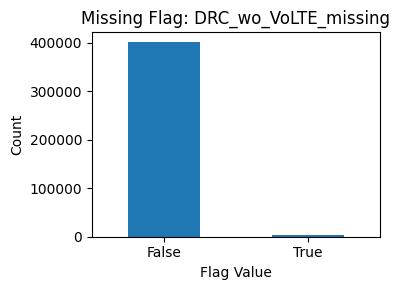

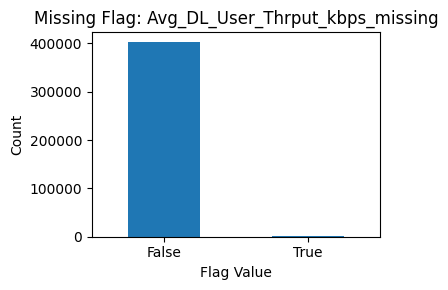

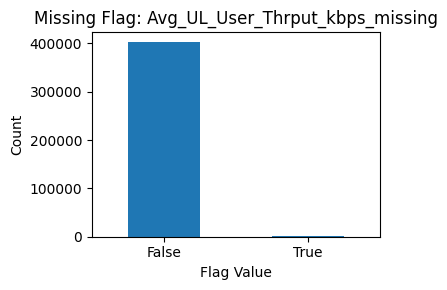

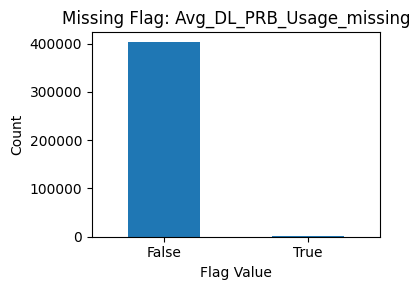

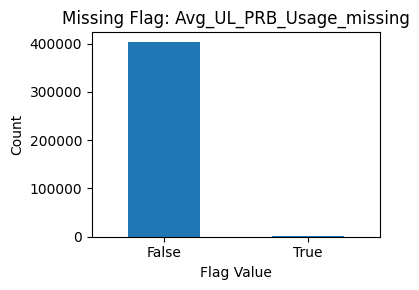

In [8]:
# Bar plots
for col in missing_flag_cols:
    plt.figure(figsize=(4, 3))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Missing Flag: {col}')
    plt.xlabel('Flag Value')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

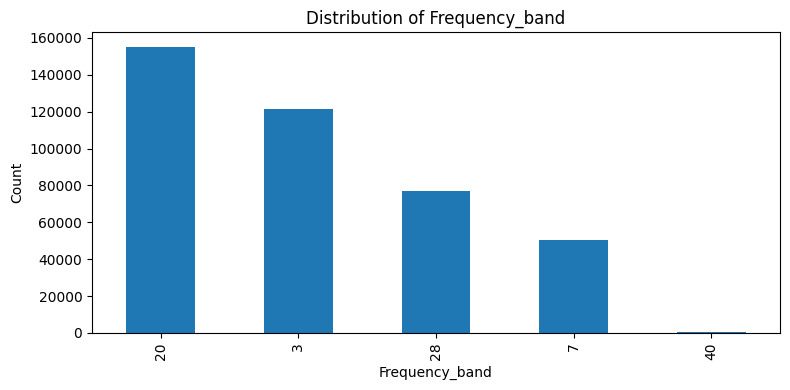

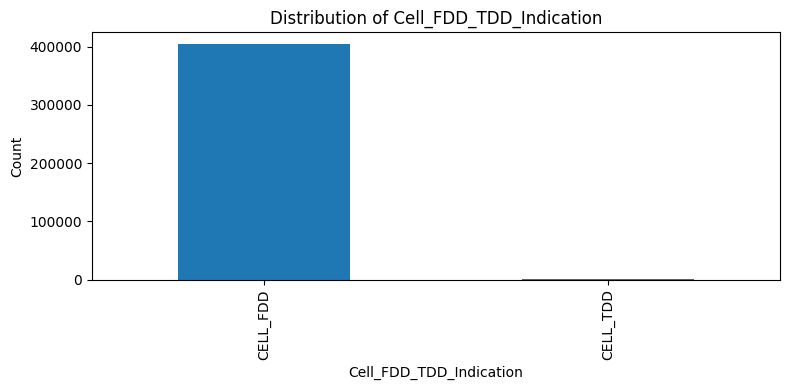

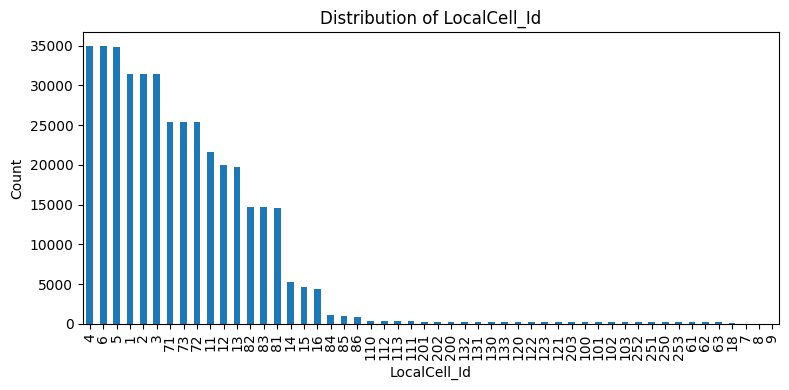

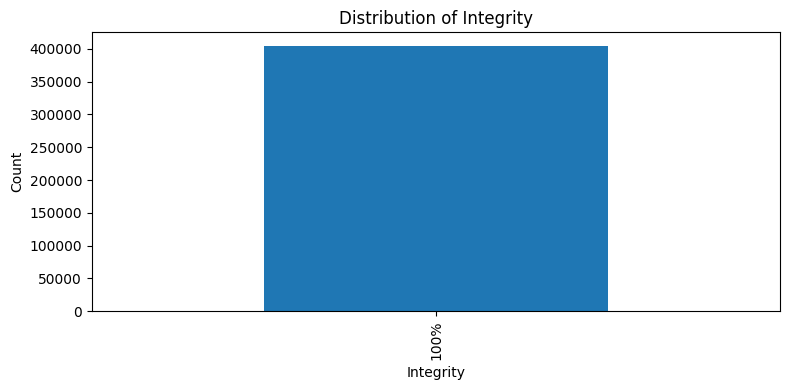

In [9]:
# Bar plots
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

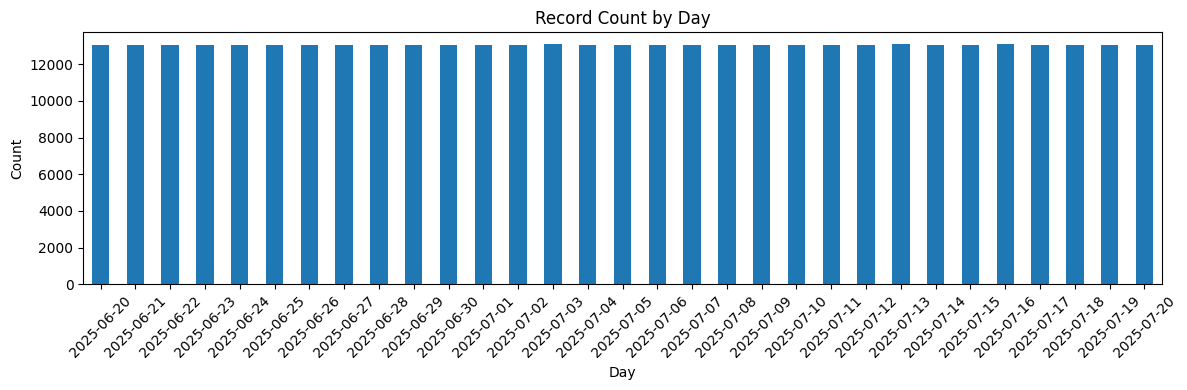

In [10]:
# Date summary
df['Date'].dt.to_period('D').value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
plt.title('Record Count by Day')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

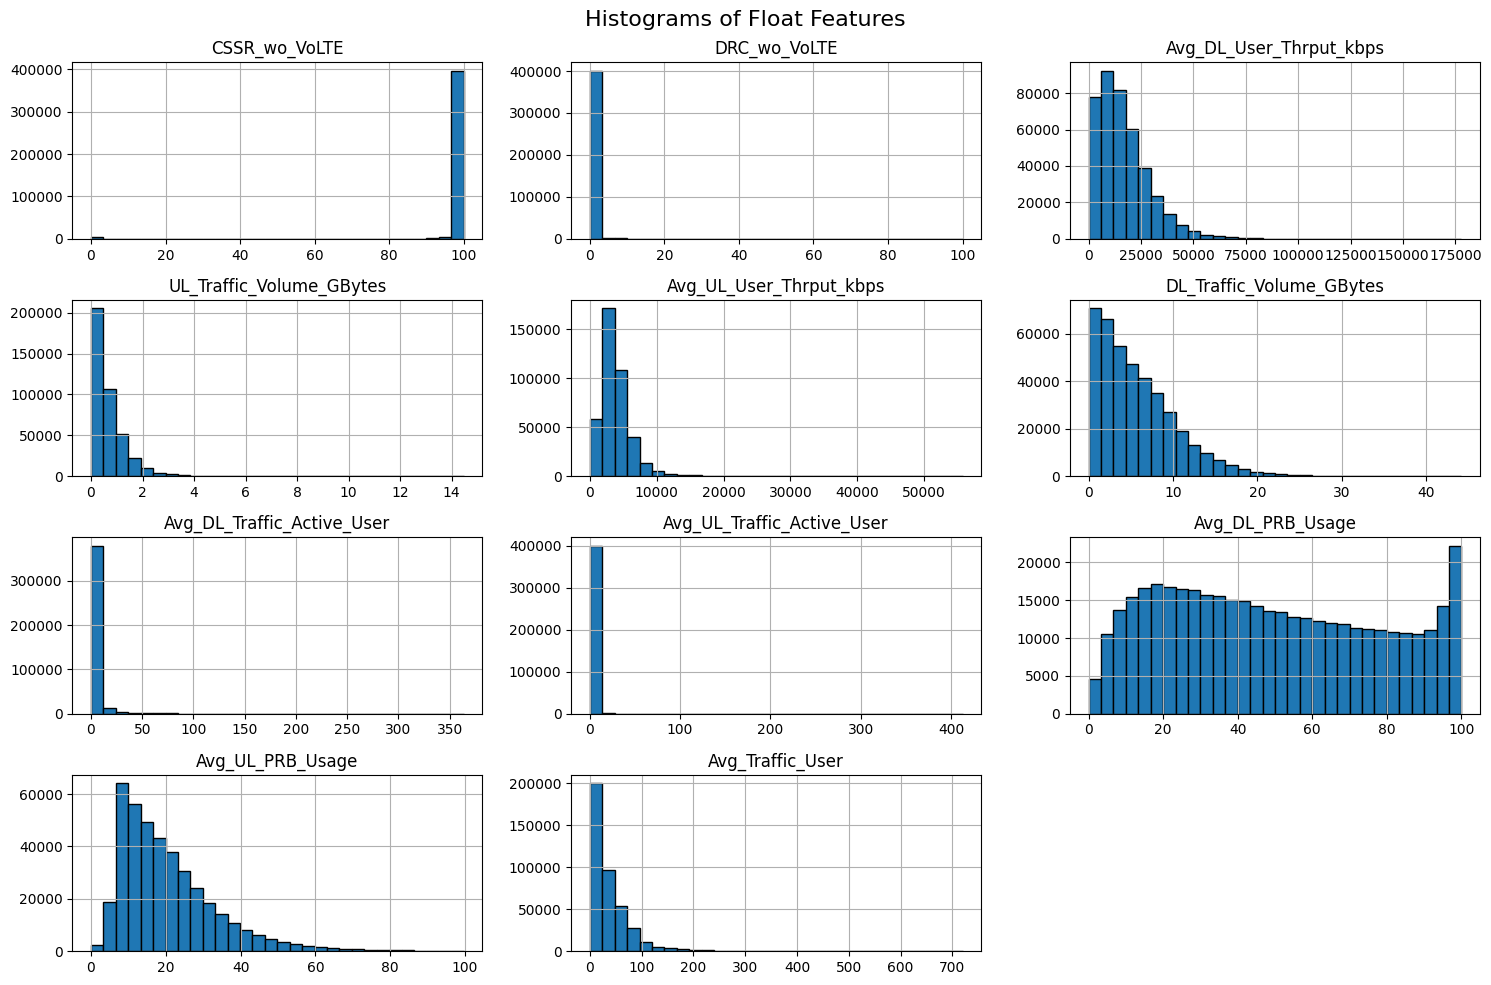

In [11]:
# Float columns histograms
df[numeric_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Float Features', fontsize=16)
plt.tight_layout()
plt.show()

### Bivariate Analysis

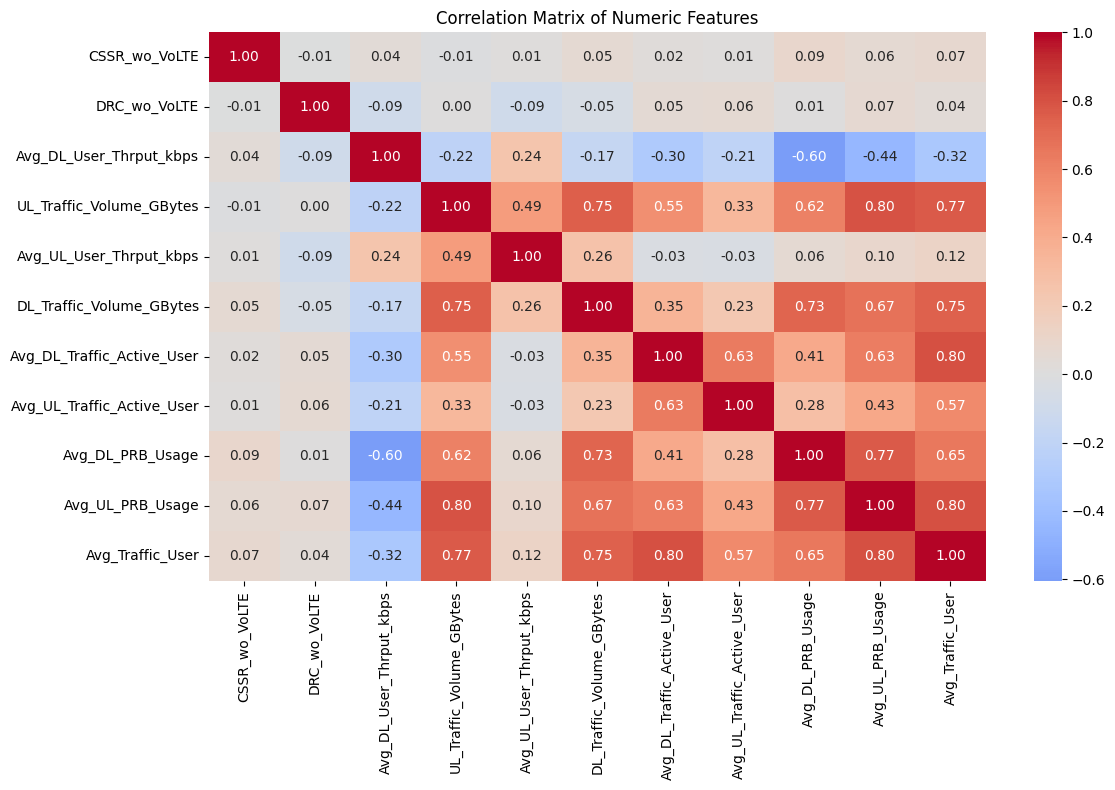

In [12]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()